In [58]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [59]:
words = open('names.txt', 'r').read().splitlines()

chars = set("".join(words))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(stoi)
print(itos)
print(vocab_size)

{'w': 1, 'z': 2, 'b': 3, 's': 4, 'h': 5, 'u': 6, 'o': 7, 'e': 8, 'x': 9, 'v': 10, 'l': 11, 'k': 12, 'f': 13, 'p': 14, 'n': 15, 'r': 16, 'y': 17, 'j': 18, 'd': 19, 'q': 20, 'g': 21, 'a': 22, 'm': 23, 'i': 24, 't': 25, 'c': 26, '.': 0}
{1: 'w', 2: 'z', 3: 'b', 4: 's', 5: 'h', 6: 'u', 7: 'o', 8: 'e', 9: 'x', 10: 'v', 11: 'l', 12: 'k', 13: 'f', 14: 'p', 15: 'n', 16: 'r', 17: 'y', 18: 'j', 19: 'd', 20: 'q', 21: 'g', 22: 'a', 23: 'm', 24: 'i', 25: 't', 26: 'c', 0: '.'}
27


In [60]:
import random
random.seed(32)
random.shuffle(words)

In [61]:
block_size = 8

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182408, 8]) torch.Size([182408])
torch.Size([22794, 8]) torch.Size([22794])
torch.Size([22944, 8]) torch.Size([22944])


In [62]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print("".join(itos[ix.item()] for ix in x), '--->', itos[y.item()])

........ ---> m
.......m ---> a
......ma ---> l
.....mal ---> a
....mala ---> y
...malay ---> a
..malaya ---> .
........ ---> a
.......a ---> n
......an ---> d
.....and ---> r
....andr ---> u
...andru ---> e
..andrue ---> .
........ ---> p
.......p ---> a
......pa ---> t
.....pat ---> r
....patr ---> i
...patri ---> k


In [63]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.randn(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias

        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias==None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
          with torch.no_grad():
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
  
    def parameters(self):
      return [self.gamma, self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class Flatten:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1]==1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:

    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [64]:
torch.manual_seed(42)

In [65]:
n_embd = 24
n_hidden = 128

model = Sequential([
    Embedding(vocab_size, n_embd),

    Flatten(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),

    Flatten(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),

    Flatten(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),

    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

76579


In [66]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
      p.data += -lr * p.grad

    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2991
  10000/ 200000: 2.0219
  20000/ 200000: 2.1965
  30000/ 200000: 2.2217
  40000/ 200000: 1.9386
  50000/ 200000: 1.8114
  60000/ 200000: 1.7935
  70000/ 200000: 2.0276
  80000/ 200000: 2.0090
  90000/ 200000: 2.0596
 100000/ 200000: 2.1930
 110000/ 200000: 1.7470
 120000/ 200000: 1.6695
 130000/ 200000: 1.6951
 140000/ 200000: 1.4678
 150000/ 200000: 1.7411
 160000/ 200000: 1.5974
 170000/ 200000: 1.5034
 180000/ 200000: 1.8323
 190000/ 200000: 1.4198


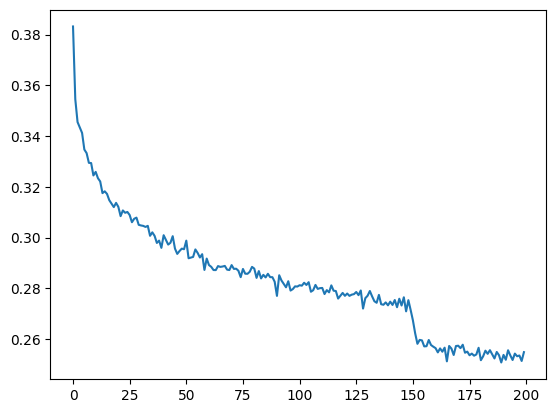

In [67]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [68]:
for layer in model.layers:
    layer.training = False

In [69]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7692559957504272
val 1.980599045753479


In [76]:
for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix==0:
            break;
    print("".join(itos[i] for i in out))

karston.
audi.
rosonni.
geovina.
coldjen.
anceli.
keynna.
borie.
sufia.
brisima.
nyserina.
calef.
loriona.
kimar.
aysaia.
sophel.
zehaan.
arly.
hadra.
alexandra.
